# Day 3: Hypothesis Testing
## Data Analysis workshop - IMBB-FORTH

### Objectives

- Understand the p-value
- Introduce permutation tests for hypothesis testing
- Apply t-test and Mann-Whitney U test
- Measure and test correlations between variables

---

## 1. Setup

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")

# Base URL for loading data from anywhere
# REPO = "https://raw.githubusercontent.com/cgenomicslab/imbb-data-analysis/main"
REPO = "../"

survey = pd.read_csv(REPO + 'data/cretan_marine_survey.csv')
print("Loaded", survey.shape[0], "sites,", survey.shape[1], "variables")

Loaded 71 sites, 17 variables


---

## 2. Question

We saw that **north-coast sites** appear to have warmer water than **south-coast sites**.

Is this a real pattern, or could it happen by chance?

This is the fundamental question behind statistical testing.

### Step 1: Look at the data

In [2]:
# Split sites into north and south groups
north = survey[survey['coast'] == 'north']
south = survey[survey['coast'] == 'south']

print("North coast:", len(north), "sites, mean temp =", round(north['water_temp'].mean(), 1), "°C")
print("South coast:", len(south), "sites, mean temp =", round(south['water_temp'].mean(), 1), "°C")
print("Difference:", round(north['water_temp'].mean() - south['water_temp'].mean(), 1), "°C")

North coast: 40 sites, mean temp = 26.0 °C
South coast: 31 sites, mean temp = 25.1 °C
Difference: 0.9 °C


The north coast looks warmer — is this statistically significant?


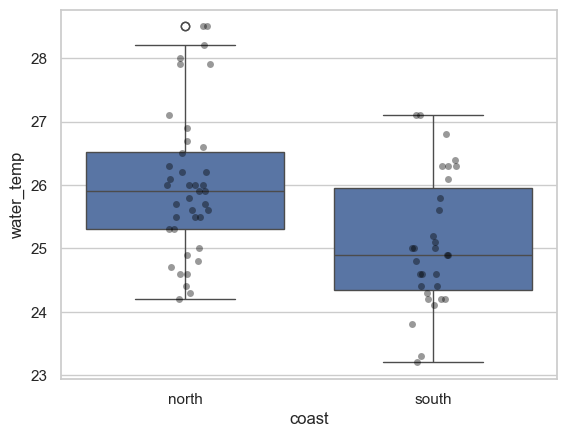

In [3]:
# Visualize the two distributions
sns.boxplot(data=survey, x='coast', y='water_temp')
sns.stripplot(data=survey, x='coast', y='water_temp',
              size=5, color='black', alpha=0.4)
print("The north coast looks warmer — is this statistically significant?")

---

## 3. Understanding P-values: Permutation Test

The idea is simple:

1. We observed a temperature difference of ~1°C between north and south.
2. If this is by chance then **the labels "north" and "south" don't matter**. Any site could be in either group.
3. We shuffle the labels randomly and recalculate the difference.
4. We do this thousands of times.
5. **How often do we get a difference as large (equal or larger) as what we actually observed?**

That proportion is the **p-value**.

### Step 2: Calculate the observed difference

In [4]:
# Our real observed difference
north_temps = north['water_temp'].values
south_temps = south['water_temp'].values

observed_diff = north_temps.mean() - south_temps.mean()
print("Observed difference:", round(observed_diff, 2), "°C")

Observed difference: 0.93 °C


### Step 3: Shuffle and repeat

If north/south labels are meaningless, we can shuffle them.
Each shuffle gives us a "fake" difference that could happen by chance.

In [5]:
# Combine all temperatures into one pool
all_temps = np.concatenate([north_temps, south_temps])
n_north = len(north_temps)

In [6]:
# Let's first test the permutation method (randomly permutes a sequence)
# Run more than once
np.random.permutation(all_temps)

array([26.3, 24.6, 26.6, 25.2, 28.5, 24.4, 24.4, 25. , 26. , 25.6, 25.7,
       24.3, 26. , 26.3, 26.3, 26.8, 24.3, 25. , 27.1, 27.9, 28. , 25.5,
       24.9, 27.1, 24.6, 24.7, 25.8, 25. , 24.1, 24.2, 25.3, 27.9, 26.5,
       24.9, 24.6, 23.2, 23.8, 26.3, 25.5, 25.1, 26. , 24.6, 26.2, 26.7,
       25.8, 24.6, 25. , 25.5, 23.3, 26.1, 26.2, 24.2, 26.4, 27.1, 24.2,
       24.2, 28.2, 25.9, 24.9, 25.9, 26. , 26.1, 24.8, 25.6, 24.8, 28.5,
       25.3, 25.6, 24.4, 26.9, 25.7])

In [7]:
# One shuffle: randomly assign labels
shuffled = np.random.permutation(all_temps)
random_north = shuffled[:n_north]
random_south = shuffled[n_north:]
random_diff = random_north.mean() - random_south.mean()

print("One random shuffle gives a difference of:", round(random_diff, 2), "°C")
print("Our observed (real) difference was:", round(observed_diff, 2), "°C")

One random shuffle gives a difference of: -0.08 °C
Our observed (real) difference was: 0.93 °C


### Step 4: Do this 10,000 times

In [8]:
# Permutation test: shuffle 10,000 times
np.random.seed(42)
n_permutations = 10000
shuffled_diffs = []

for i in range(n_permutations):
    shuffled = np.random.permutation(all_temps)
    random_diff = shuffled[:n_north].mean() - shuffled[n_north:].mean()
    shuffled_diffs.append(random_diff)

shuffled_diffs = np.array(shuffled_diffs)
print("Generated", n_permutations, "random differences")
print("Range:", round(shuffled_diffs.min(), 2), "to", round(shuffled_diffs.max(), 2), "°C")

Generated 10000 random differences
Range: -1.06 to 1.05 °C


### Step 5: Where does our real observation fall?

This is key. The histogram shows what differences look like **under pure chance (null distribution)**.
The red line shows what we **actually observed**.

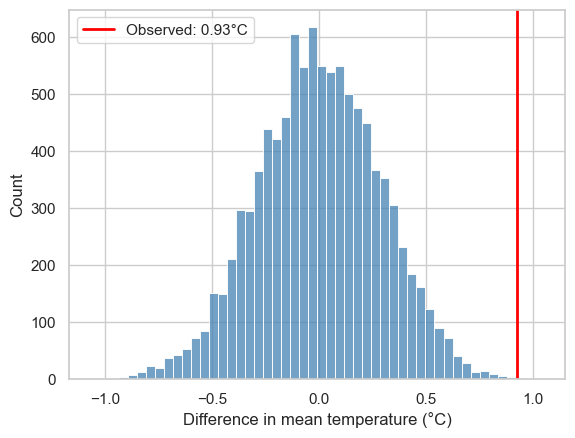

The red line is far from the center — our observation is rare under random chance.


In [9]:
# Plot the null distribution
sns.histplot(shuffled_diffs, bins=50, color='steelblue')

# Mark our observed difference
plt.axvline(observed_diff, color='red', linewidth=2,
            label='Observed: ' + str(round(observed_diff, 2)) + '°C')
plt.xlabel('Difference in mean temperature (°C)')
plt.ylabel('Count')
plt.legend()
plt.show()

print("The red line is far from the center — our observation is rare under random chance.")

### Step 6: Calculate the p-value

In [10]:
# P-value: how often is a random difference >= our observed difference?
p_value = np.sum(np.abs(shuffled_diffs) >= np.abs(observed_diff)) / n_permutations

print("Observed difference:", round(observed_diff, 2), "°C")
print("P-value:", p_value)
print()
if p_value < 0.05:
    print("p < 0.05: The difference is statistically significant.")
    print("It would be very unlikely to see this difference if north/south didn't matter.")
else:
    print("p >= 0.05: The difference is not statistically significant.")
    print("A difference this large could happen by chance.")

Observed difference: 0.93 °C
P-value: 0.0008

p < 0.05: The difference is statistically significant.
It would be very unlikely to see this difference if north/south didn't matter.


### What the p-value means

What the p-value answers:

> **If there were no real difference, how likely would it be to see a result as extreme as this?**

A small p-value (< 0.05) means our observation is **rare under the assumption of no difference**.
It does not prove the difference is real — it says it would be surprising if it weren't.

---

## 4. Standard Statistical Tests

The permutation test is intuitive and samples the actual distribution of the data. In practice, there are established tests that give similar answers.

### T-test (parametric)

Assumes data are roughly normally distributed. Tests whether two group means differ.

In [11]:
# T-test: are north and south temperatures different?
t_stat, p_ttest = stats.ttest_ind(north_temps, south_temps)

print("T-statistic:", round(t_stat, 2))
print("P-value:", round(p_ttest, 6))

T-statistic: 3.48
P-value: 0.00087


### Mann-Whitney U test (non-parametric)

Does not assume normal distributions. Tests whether one group tends to have larger values.

In [12]:
# Mann-Whitney U: non-parametric alternative
u_stat, p_mann = stats.mannwhitneyu(north_temps, south_temps, alternative='two-sided')

print("U-statistic:", round(u_stat, 0))
print("P-value:", round(p_mann, 6))

U-statistic: 882.0
P-value: 0.002367


### Comparison

All three methods agree:

In [13]:
# Compare all three results
print("Method               P-value       Significant?")
print("-" * 48)
print("Permutation test    ", round(p_value, 4), "       ", "Yes" if p_value < 0.05 else "No")
print("T-test              ", round(p_ttest, 4), "       ", "Yes" if p_ttest < 0.05 else "No")
print("Mann-Whitney U      ", round(p_mann, 4), "       ", "Yes" if p_mann < 0.05 else "No")

Method               P-value       Significant?
------------------------------------------------
Permutation test     0.0008         Yes
T-test               0.0009         Yes
Mann-Whitney U       0.0024         Yes


### 💡 Exercise 3.1: Test Another Comparison

**Task:** Do pebble sites have more fireworms than sandy sites?

1. Get fireworm density for pebble and sandy sites
2. Calculate the observed difference in means
3. Run a t-test
4. Is the difference significant?

In [14]:
# Your code here
pebble_fw = survey[survey['substrate'] == 'pebble']['fireworms_per_m2'].values
sandy_fw = survey[survey['substrate'] == 'sandy']['fireworms_per_m2'].values

print("Pebble mean:", round(pebble_fw.mean(), 2), "fireworms/m², n =", len(pebble_fw))
print("Sandy mean:", round(sandy_fw.mean(), 2), "fireworms/m², n =", len(sandy_fw))

# Run t-test
t, p = # Your code
print("T-test p-value:", round(p, 4))

SyntaxError: invalid syntax (736066190.py, line 9)

---

## 5. Correlation

Correlation measures how two variables change together.

**Pearson correlation (r)** ranges from -1 to +1:
- **r = +1**: perfect positive relationship (both increase together)
- **r = 0**: no linear relationship
- **r = -1**: perfect negative relationship (one increases, the other decreases)

### Tourism vs Posidonia

Pearson r = -0.383
P-value = 0.001
Negative correlation: more tourists → less seagrass


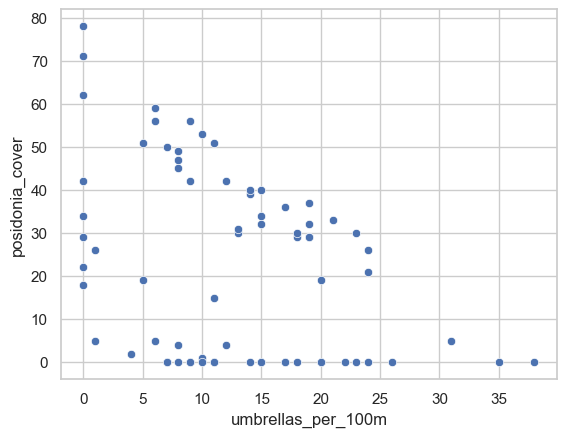

In [15]:
# Does tourism damage seagrass?
sns.scatterplot(data=survey, x='umbrellas_per_100m', y='posidonia_cover')

r, p = stats.pearsonr(survey['umbrellas_per_100m'], survey['posidonia_cover'])
print("Pearson r =", round(r, 3))
print("P-value =", round(p, 4))
print("Negative correlation: more tourists → less seagrass")

### Lionfish vs Cornetfish

Pearson r = 0.869
P-value = 0.0
Strong positive correlation: these invasive species tend to co-occur


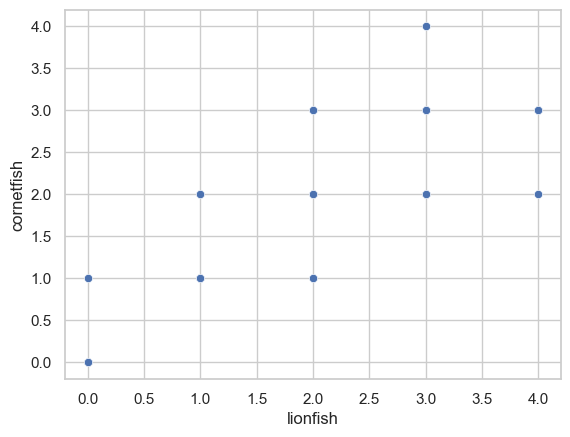

In [16]:
# Two invasive species: do they co-occur?
sns.scatterplot(data=survey, x='lionfish', y='cornetfish')

r, p = stats.pearsonr(survey['lionfish'], survey['cornetfish'])
print("Pearson r =", round(r, 3))
print("P-value =", round(p, 4))
print("Strong positive correlation: these invasive species tend to co-occur")

### Posidonia Cover vs Seahorses

Pearson r = 0.936
P-value = 0.0
Strong positive correlation: seahorses depend on posidonia seagrass


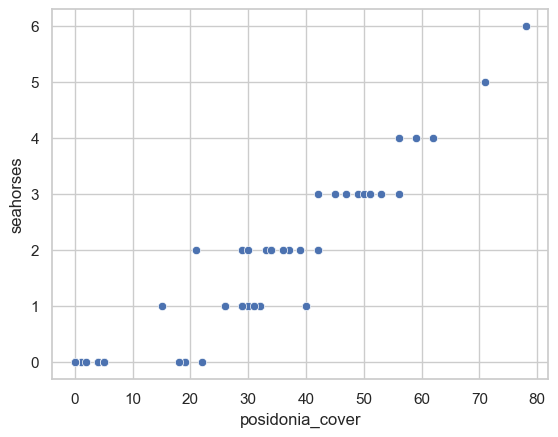

In [17]:
# Does posidonia seagrass predict seahorse abundance?
sns.scatterplot(data=survey, x='posidonia_cover', y='seahorses')

r, p = stats.pearsonr(survey['posidonia_cover'], survey['seahorses'])
print("Pearson r =", round(r, 3))
print("P-value =", round(p, 6))
print("Strong positive correlation: seahorses depend on posidonia seagrass")

### Correlation Heatmap

We can visualize all pairwise correlations at once. We show only the lower triangle to avoid redundancy.

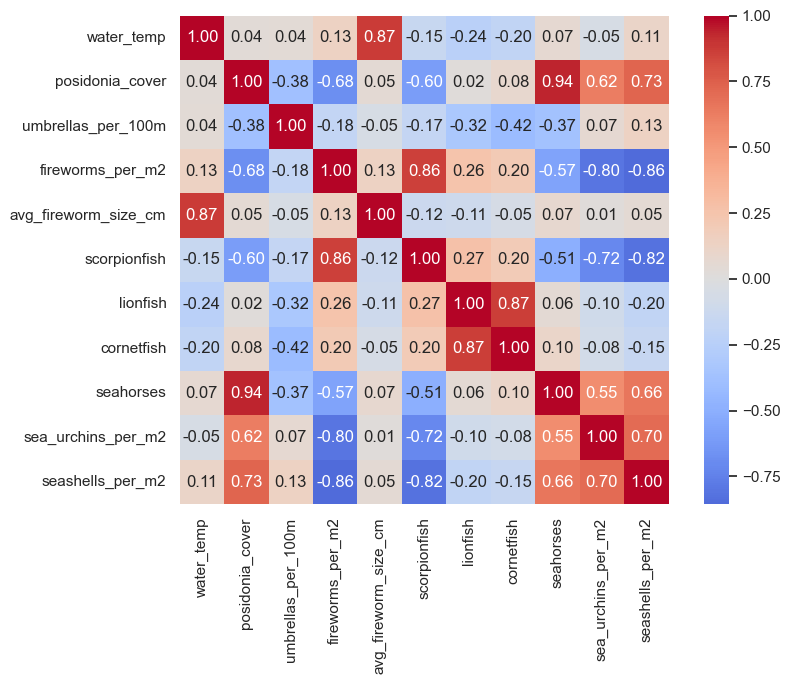

Red = positive correlation, Blue = negative correlation


In [18]:
# Select numerical columns for correlation
num_cols = ['water_temp', 'posidonia_cover', 'umbrellas_per_100m',
            'fireworms_per_m2', 'avg_fireworm_size_cm',
            'scorpionfish', 'lionfish', 'cornetfish',
            'seahorses', 'sea_urchins_per_m2', 'seashells_per_m2']

corr_matrix = survey[num_cols].corr()

# Lower triangle only
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', #mask=mask,
            cmap='coolwarm', center=0, square=True)
plt.tight_layout()
plt.show()
print("Red = positive correlation, Blue = negative correlation")

### 💡 Exercise 3.2: Explore Correlations

**Task:**
1. Test the correlation between `umbrellas_per_100m` and `seahorses`. Is it significant? Why might this happen?
2. Test the correlation between `fireworms_per_m2` and `sea_urchins_per_m2`.
3. Look at the heatmap. Which pair of variables has the strongest positive correlation?

In [19]:
# 1. Umbrellas vs seahorses
r, p = # Your code
print("Umbrellas vs seahorses: r =", round(r, 3), ", p =", round(p, 4))
# Think: is this a direct relationship or mediated through posidonia?

# 2. Fireworms vs sea urchins
r, p = # Your code
print("Fireworms vs urchins: r =", round(r, 3), ", p =", round(p, 4))

# 3. Strongest positive correlation from the heatmap?
# Your answer: 

SyntaxError: invalid syntax (3503172987.py, line 2)

---

## 6. Fluorescence: The Temperature → Size → Wavelength Chain

Yesterday we saw that fireworm fluorescence shifts from green to orange with body size. Now let's test this statistically.

In [20]:
# Filter to night surveys (the only ones with fluorescence data)
night = survey[survey['night_survey'] == True].copy()
print(f"Night surveys: {len(night)} sites")

Night surveys: 30 sites


In [21]:
# Correlation: temperature → fireworm size
r, p = stats.pearsonr(survey['water_temp'], survey['avg_fireworm_size_cm'])
print("Temperature vs fireworm size: r =", round(r, 3), ", p =", round(p, 6))
print("Warmer water grows larger fireworms (thermophilic)")

Temperature vs fireworm size: r = 0.87 , p = 0.0
Warmer water grows larger fireworms (thermophilic)


In [22]:
# Correlation: fireworm size → fluorescence peak (night surveys only)
r, p = stats.pearsonr(night['avg_fireworm_size_cm'], night['fluor_peak_nm'])
print("Fireworm size vs emission peak: r =", round(r, 3), ", p =", round(p, 6))
print("Larger worms emit at longer wavelengths (green → orange → red)")

Fireworm size vs emission peak: r = 0.953 , p = 0.0
Larger worms emit at longer wavelengths (green → orange → red)


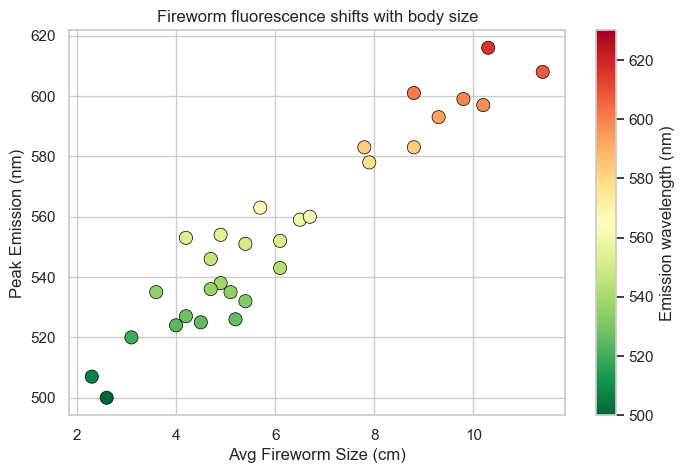

The fluorescent molecules producing these colors are unknown.
Not GFP, not any characterized fluorescent protein.


In [23]:
# The full chain: scatter plot colored by emission wavelength
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(night['avg_fireworm_size_cm'], night['fluor_peak_nm'],
                     c=night['fluor_peak_nm'], cmap='RdYlGn_r',
                     s=90, edgecolor='black', linewidth=0.5,
                     vmin=500, vmax=630)
plt.colorbar(scatter, label='Emission wavelength (nm)')
ax.set_xlabel('Avg Fireworm Size (cm)')
ax.set_ylabel('Peak Emission (nm)')
ax.set_title('Fireworm fluorescence shifts with body size')
plt.show()

print("The fluorescent molecules producing these colors are unknown.")
print("Not GFP, not any characterized fluorescent protein.")

---

## 7. Visualize First

Good practice!: **look at your data before running any test.**

Let's compare north and south temperature distributions properly.

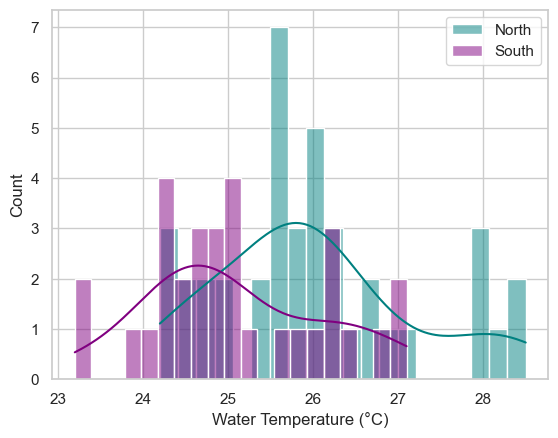

The distributions overlap — the test quantifies whether the shift is significant.


In [24]:
# Overlapping histograms
sns.histplot(north['water_temp'], color='teal', label='North', kde=True, alpha=0.5, bins=20)
sns.histplot(south['water_temp'], color='purple', label='South', kde=True, alpha=0.5, bins=20)
plt.xlabel('Water Temperature (°C)')
plt.legend()
plt.show()

print("The distributions overlap — the test quantifies whether the shift is significant.")

---

## 💡 Final Exercise: Full Analysis

**Task:** Is there a difference in lionfish abundance between north-coast and south-coast sites?

Lionfish (*Pterois miles*) entered the Mediterranean via the Suez Canal and are spreading along Crete's south coast.

1. Calculate mean lionfish for each coast
2. Visualize the two distributions
3. Run a permutation test (1000 shuffles is enough)
4. Run a Mann-Whitney U test (why might this be better than a t-test for count data?)
5. What do you conclude?

In [ ]:
# Your code here

# 1. Group means
north_lion = # Your code
south_lion = # Your code

print("North mean lionfish:", round(north_lion.mean(), 1))
print("South mean lionfish:", round(south_lion.mean(), 1))

# 2. Visualize
# Your code

# 3. Permutation test
# Your code

# 4. Mann-Whitney U test
# Your code

# 5. Conclusion?


---

## Summary

### What is a p-value?

The p-value tells you: **if there were no real effect, how often would we find a result as extreme as what we observed by random chance**

### Core Concepts
- **Permutation test** — estimate significance by shuffling labels and measuring how extreme your observation is
- **T-test** — parametric test for difference in means
- **Mann-Whitney U** — non-parametric test (no normality assumption)
- **Pearson correlation** — measures linear relationship strength (r) and significance (p)

### Key Functions
- `stats.ttest_ind(group1, group2)` — independent samples t-test
- `stats.mannwhitneyu(group1, group2)` — Mann-Whitney U test
- `stats.pearsonr(x, y)` — Pearson correlation with p-value

### Key Take-home

1. **Visualize first, test second**
2. The p-value is not the probability that your hypothesis is true
3. Statistical significance is not the same as biological importance
4. Effect size matters — a tiny difference can be "significant" with enough data

### Tomorrow: Day 4

- **Enrichment analysis** — are certain categories over-represented in a subset? Same permutation logic, different application
- **Differential expression** — which genes change between conditions?
- **Dimensionality reduction** — PCA and UMAP for visualizing high-dimensional data
